# Infraslow fluctuation of sigma power — grand-average Fig C-i across subjects

Same flow as `demo_infraslow_yasa.ipynb`, but for a 10-subject cohort. Per subject we:

1. find artifact-free **NREM-2 bouts >= 200 s** that contain **>=1 detected spindle** (`MIN_BOUT_SEC`),
2. take the dB sigma-power (10-16 Hz) course and its per-bout infraslow spectra,
3. average across bouts, normalize to relative spectral power, and **baseline-correct**
   over 0.06-0.1 Hz.

We then average the relative spectra **across subjects** (mean + SEM band) and reproduce
**Fig C-i** on the grand average: a Gaussian fit giving peak frequency, bandwidth (+/-1 SD)
and area under the curve, with the detection threshold.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

from infraslow import BioserenityPSGLoader
from infraslow.processing.detection import (
    spindles_detect,
    _extract_epoch_stages,
    _stages_to_int,
    DEFAULT_STAGE_MAP,
    DEFAULT_EPOCH_SEC,
)
from infraslow.processing.infraslow import (
    power_envelope,
    infraslow_spectrum,
    DEFAULT_SF_ENV,
    DEFAULT_INFRASLOW_BAND,
)

plt.rcParams['figure.dpi'] = 110
PURPLE, LPURPLE = '#5b2a86', '#c9b3e6'
_trapz = getattr(np, 'trapezoid', np.trapz)   # NumPy 2.0 renamed trapz

In [2]:
# Cohort: 10 control subjects (subject_id -> group).
SUBJECTS = {
    "318679": "control",
    "318769": "control",
    "318919": "control",
    "319018": "control",
    "319040": "control",
    "319046": "control",
    "319061": "control",
    "319076": "control",
    "319113": "control",
    "319118": "control",
}

SF = 128.0                     # common resample rate (Hz) for every subject
CHANNEL = "C3"                 # analysis channel for the sigma-power envelope
SIGMA_BAND = (10.0, 16.0)      # Fig B: sigma power over 10-16 Hz
INFRASLOW_BAND = DEFAULT_INFRASLOW_BAND
BASELINE_BAND = (0.06, 0.1)    # Fig C-i: baseline-correction band (red line)
MIN_BOUT_SEC = 200.0           # consecutive artifact-free N2 bouts >= 200 s
EPOCH_SEC = DEFAULT_EPOCH_SEC  # 30 s scored epochs
# Fixed Welch window (< shortest bout) so every subject shares one frequency grid.
WINDOW_SEC = 100

In [3]:
def nrem2_bouts(loader, *, epoch_sec=EPOCH_SEC, min_dur=MIN_BOUT_SEC, stage_code=2):
    """(start, stop) times (s) of runs of consecutive N2 epochs lasting >= min_dur."""
    codes = _stages_to_int(
        _extract_epoch_stages(loader.annotations, stage_column='stage'),
        DEFAULT_STAGE_MAP,
    )
    bouts, i, n = [], 0, len(codes)
    while i < n:
        if codes[i] == stage_code:
            j = i
            while j < n and codes[j] == stage_code:
                j += 1
            if (j - i) * epoch_sec >= min_dur:
                bouts.append((i * epoch_sec, j * epoch_sec))
            i = j
        else:
            i += 1
    return bouts

def gaussian(f, amp, mu, sd):
    return amp * np.exp(-0.5 * ((f - mu) / sd) ** 2)

def fit_isfs(freqs, corrected):
    """Fig C-i parameters from a baseline-corrected relative spectrum."""
    base_m = (freqs >= BASELINE_BAND[0]) & (freqs <= BASELINE_BAND[1])
    fit_m = (freqs >= INFRASLOW_BAND[0]) & (freqs < BASELINE_BAND[0])
    ff, yy = freqs[fit_m], corrected[fit_m]
    p0 = [max(yy.max(), 1e-9), ff[np.argmax(yy)], 0.01]
    popt, _ = curve_fit(gaussian, ff, yy, p0=p0,
                        bounds=([0, INFRASLOW_BAND[0], 1e-3], [np.inf, BASELINE_BAND[0], 0.05]),
                        maxfev=10000)
    amp, mu, sd = popt
    lo, hi = mu - sd, mu + sd            # +/-1 SD around the peak frequency
    bandwidth = hi - lo                  # = 2*sd (variability in period)
    f_auc = np.linspace(lo, hi, 400)     # fine grid: coarse PSD bins undercount the area
    auc = float(_trapz(gaussian(f_auc, *popt), f_auc))   # power within the SAME +/-1 SD range
    threshold = 1.5 * corrected[base_m].std()   # 1.5x SD of the baseline-band (noise) spectrum
    return dict(popt=popt, amp=amp, mu=mu, sd=sd, lo=lo, hi=hi,
                bandwidth=bandwidth, auc=auc,
                threshold=threshold, detected=bool(amp > threshold))

In [4]:
# Load one loader per subject; skip any that fail (missing EDF, unresolved channel).
loaders = {}
for sid in SUBJECTS:
    try:
        loaders[sid] = BioserenityPSGLoader(
            subject_id=sid, sf=SF, requested_channels=[CHANNEL]
        ).load()
    except Exception as exc:
        print(f"skip {sid}: {exc}")

print(f"Loaded {len(loaders)}/{len(SUBJECTS)} subjects: {list(loaders)}")

initiated lunapi 1.4.0 <lunapi.lunapi0.luna object at 0x7f5cffd4a7f0> 



  *** warning, signal 13 ( TFlo ) has a non-integer SR
  *** may wish to use RECORD-SIZE if this is due to a fractional EDF record size
  *** (it will resample signals to fit in a new regular, e.g. dur=1, record size)
    - record size        = 2 seconds
    - samples per record = 25
    - implied SR         = 25 / 2 = 12.5
  *** warning, signal 14 ( CFlo ) has a non-integer SR
  *** may wish to use RECORD-SIZE if this is due to a fractional EDF record size
  *** (it will resample signals to fit in a new regular, e.g. dur=1, record size)
    - record size        = 2 seconds
    - samples per record = 25
    - implied SR         = 25 / 2 = 12.5
  *** warning, signal 15 ( Tho ) has a non-integer SR
  *** may wish to use RECORD-SIZE if this is due to a fractional EDF record size
  *** (it will resample signals to fit in a new regular, e.g. dur=1, record size)
    - record size        = 2 seconds
    - samples per record = 25
    - implied SR         = 25 / 2 = 12.5
  *** warning, signal 1

initiated lunapi 1.4.0 <lunapi.lunapi0.luna object at 0x7f5cffd4a7f0> 



___________________________________________________________________
Processing: 318769 | /oak/stanford/groups/mignot/psg/Bioserenity/edf/318769.edf
 duration 07.48.36, 28116s | time 22.08.01 - 05.56.37 | date 01.01.12

 signals: 29 (of 29) selected in an EDF+C file
  F3 | F4 | C3 | C4 | O1 | O2 | LOC | ROC
  ECG | emg_Chin | emg_RLeg | emg_LLeg | Tho | Abd | SpO2 | flow_PFlo
  flow_TFlo | flow_CFlo | PPG | Snore | imp | rr | Leak | EPAP
  IPAP | Body | sao2 | HR | EDF Annotations
  extracting 'EDF Annotations' track from EDF+


initiated lunapi 1.4.0 <lunapi.lunapi0.luna object at 0x7f5cffd4a7f0> 



...

initiated lunapi 1.4.0 <lunapi.lunapi0.luna object at 0x7f5cffd4a7f0> 



___________________________________________________________________
Processing: 319113 | /oak/stanford/groups/mignot/psg/Bioserenity/edf/319113.edf
 duration 07.18.49, 26329s | time 21.55.36 - 05.14.25 | date 01.01.12

 signals: 27 (of 27) selected in an EDF+C file
  F3 | F4 | C3 | C4 | O1 | O2 | LOC | ROC
  ECG | emg_Chin | emg_RLeg | emg_LLeg | Tho | Abd | SpO2 | flow_PFlo
  flow_TFlo | flow_CFlo | Snore | IPAP | EPAP | Leak | Body | Pulse
  sao2 | HR | EDF Annotations
  extracting 'EDF Annotations' track from EDF+


initiated lunapi 1.4.0 <lunapi.lunapi0.luna object at 0x7f5cffd4a7f0> 



___________________________________________________________________
Processing: 319118 | /oak/stanford/groups/mignot/psg/Bioserenity/edf/319118.edf
 duration 06.32.08, 23528s | time 23.11.29 - 05.43.37 | date 01.01.12

 signals: 28 (of 28) selected in an EDF+C file
  F3 | F4 | C3 | C4 | O1 | O2 | LOC | ROC
  ECG | emg_Chin | emg_RLeg | emg_LLeg | Tho | Abd | SpO2 | flow_PFlo
  flow_TFlo | flow_CFlo | Snore | imp | rr | Leak | EPAP | IPAP
  Body | sao2 | HR | EDF Annotations
  extracting 'EDF Annotations' track from EDF+


Loaded 10/10 subjects: ['318679', '318769', '318919', '319018', '319040', '319046', '319061', '319076', '319113', '319118']


## Per-subject relative spectral power over N2 bouts

For each subject: one Welch spectrum per bout on a common grid, averaged across bouts,
normalized to unit in-band area (relative spectral power), then baseline-corrected.

In [5]:
freqs = None
rel_by_subj, corr_by_subj = {}, {}
band_m = base_m = None

for sid, loader in loaders.items():
    bouts = nrem2_bouts(loader)
    if not bouts:
        print(f"skip {sid}: no N2 bout >= {MIN_BOUT_SEC:g}s")
        continue
    # keep only N2 bouts that contain >= 1 detected spindle (drop spindle-free bouts)
    sp = spindles_detect(loader, ch_names=CHANNEL, include=(2,))
    peaks = sp.summary()['Peak'].to_numpy() if sp is not None else np.empty(0)
    bouts = [(a, b) for a, b in bouts if np.any((peaks >= a) & (peaks < b))]
    if not bouts:
        print(f"skip {sid}: no bout with a detected spindle")
        continue
    data = np.asarray(loader.get_channel(CHANNEL), dtype=float)
    sf = float(loader.sf)
    t_env, sigma_db = power_envelope(
        data, sf, band=SIGMA_BAND, sf_env=DEFAULT_SF_ENV, smooth_sec=1.0, to_db=True
    )
    segs = [sigma_db[(t_env >= a) & (t_env < b)] for a, b in bouts]
    segs = [s for s in segs if len(s) >= WINDOW_SEC]
    if not segs:
        print(f"skip {sid}: bouts shorter than the {WINDOW_SEC:g}s window")
        continue
    specs = [infraslow_spectrum(s, DEFAULT_SF_ENV, infraslow_band=INFRASLOW_BAND, window_sec=WINDOW_SEC)
             for s in segs]
    if freqs is None:
        freqs = specs[0].freqs
        band_m = (freqs >= INFRASLOW_BAND[0]) & (freqs <= INFRASLOW_BAND[1])
        base_m = (freqs >= BASELINE_BAND[0]) & (freqs <= BASELINE_BAND[1])
    mean_psd = np.mean([sp_.psd for sp_ in specs], axis=0)
    rel = mean_psd / _trapz(mean_psd[band_m], freqs[band_m])
    rel_by_subj[sid] = rel
    corr_by_subj[sid] = rel - rel[base_m].mean()
    print(f"{sid}: {len(segs)} bout(s)")

n = len(corr_by_subj)
print(f"\n{n} subject(s) with usable bouts")

17-Jul-26 15:55:53 | WARNING | Hypnogram is SHORTER than data by 30.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.
17-Jul-26 15:55:59 | WARNING | Hypnogram is SHORTER than data by 6.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.


318679: 23 bout(s)


17-Jul-26 15:56:04 | WARNING | Hypnogram is SHORTER than data by 23.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.


318769: 9 bout(s)


17-Jul-26 15:56:13 | WARNING | Hypnogram is SHORTER than data by 18.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.


...

319061: 13 bout(s)


17-Jul-26 15:56:45 | WARNING | Hypnogram is SHORTER than data by 19.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.


319076: 13 bout(s)


17-Jul-26 15:56:51 | WARNING | Hypnogram is SHORTER than data by 8.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.


319113: 8 bout(s)
319118: 12 bout(s)

10 subject(s) with usable bouts


## Grand average across subjects + Fig C-i

Mean +/- SEM of the relative spectral power across subjects, with the Gaussian fit and ISFS
parameters estimated on the grand-average corrected spectrum.

In [6]:
rel_stack = np.vstack([rel_by_subj[s] for s in corr_by_subj])
corr_stack = np.vstack([corr_by_subj[s] for s in corr_by_subj])
rel_mean, rel_sem = rel_stack.mean(0), rel_stack.std(0, ddof=1) / np.sqrt(n)
corr_mean, corr_sem = corr_stack.mean(0), corr_stack.std(0, ddof=1) / np.sqrt(n)
baseline = rel_mean[base_m].mean()

fit = fit_isfs(freqs, corr_mean)
print(f"Grand-average ISFS detected: {fit['detected']} | "
      f"peak {fit['mu']:.4f} Hz (~{1/fit['mu']:.0f} s), "
      f"bandwidth {fit['lo']:.4f}-{fit['hi']:.4f} Hz, AUC {fit['auc']:.3g}")

Grand-average ISFS detected: True | peak 0.0239 Hz (~42 s), bandwidth 0.0095-0.0383 Hz, AUC 0.271


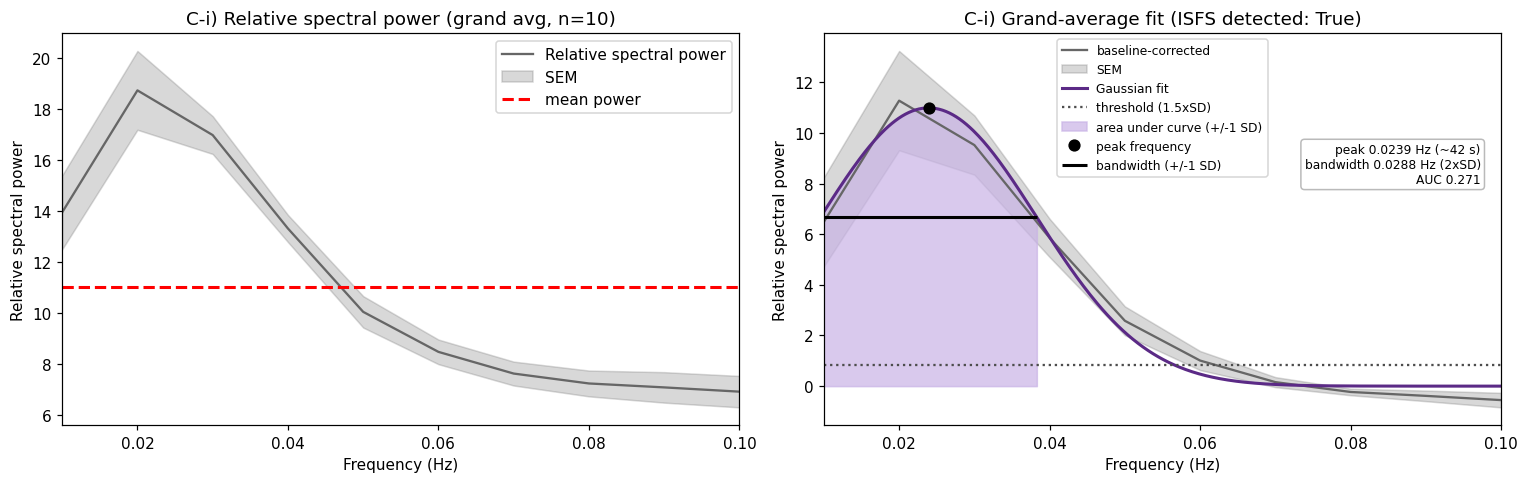

In [7]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 4.5))
bm = band_m

# --- Left: grand-average relative spectral power (+/- SEM) + baseline band ---
axL.plot(freqs[bm], rel_mean[bm], color='0.4', lw=1.5, label='Relative spectral power')
axL.fill_between(freqs[bm], (rel_mean - rel_sem)[bm], (rel_mean + rel_sem)[bm],
                 color='0.4', alpha=0.25, label='SEM')
mean_power = rel_mean[bm].mean()
axL.axhline(mean_power, color='red', lw=2, ls='--', label='mean power')
axL.set(xlim=INFRASLOW_BAND, xlabel='Frequency (Hz)', ylabel='Relative spectral power',
        title=f'C-i) Relative spectral power (grand avg, n={n})')
axL.legend(frameon=True)

# --- Right: baseline-corrected grand average (+/- SEM) + Gaussian fit + params ---
axR.plot(freqs[bm], corr_mean[bm], color='0.4', lw=1.5, label='baseline-corrected')
axR.fill_between(freqs[bm], (corr_mean - corr_sem)[bm], (corr_mean + corr_sem)[bm],
                 color='0.4', alpha=0.25, label='SEM')
fg = np.linspace(*INFRASLOW_BAND, 400)
axR.plot(fg, gaussian(fg, *fit['popt']), color=PURPLE, lw=2, label='Gaussian fit')
axR.axhline(fit['threshold'], ls=':', color='0.3', label='threshold (1.5xSD)')
f_auc = np.linspace(fit['lo'], fit['hi'], 400)
axR.fill_between(f_auc, gaussian(f_auc, *fit['popt']), color=LPURPLE,
                 alpha=0.7, label='area under curve (+/-1 SD)')
axR.plot([fit['mu']], [gaussian(fit['mu'], *fit['popt'])], 'o', color='k', ms=7, zorder=5,
         label='peak frequency')
axR.hlines(gaussian(fit['lo'], *fit['popt']), fit['lo'], fit['hi'], color='k', lw=2,
           label='bandwidth (+/-1 SD)')
axR.text(0.97, 0.72,
         f"peak {fit['mu']:.4f} Hz (~{1/fit['mu']:.0f} s)\n"
         f"bandwidth {fit['bandwidth']:.4f} Hz (2xSD)\n"
         f"AUC {fit['auc']:.3g}",
         transform=axR.transAxes, ha='right', va='top', fontsize=8,
         bbox=dict(boxstyle='round', fc='white', ec='0.7', alpha=0.9))
axR.set(xlim=INFRASLOW_BAND, xlabel='Frequency (Hz)', ylabel='Relative spectral power',
        title=f"C-i) Grand-average fit (ISFS detected: {fit['detected']})")
axR.legend(frameon=True, fontsize=8)
fig.tight_layout()
plt.show()

## Per-subject ISFS parameters (mean +/- SEM)

Fig C-i fit applied to each subject's own corrected spectrum, then summarised across the cohort.

In [8]:
rows = []
for sid in corr_by_subj:
    try:
        f_ = fit_isfs(freqs, corr_by_subj[sid])
    except Exception as exc:
        print(f"fit failed for {sid}: {exc}")
        continue
    rows.append({
        'subject': sid, 'group': SUBJECTS[sid],
        'peak_freq': f_['mu'], 'peak_period_s': 1 / f_['mu'],
        'bandwidth_hz': f_['bandwidth'], 'auc': f_['auc'],
        'detected': f_['detected'],
    })

metrics = pd.DataFrame(rows)
display(metrics.round(4))

summary = metrics[['peak_freq', 'peak_period_s', 'bandwidth_hz', 'auc']].agg(['mean', 'sem'])
display(summary.round(4))

,subject,group,peak_freq,peak_period_s,bandwidth_hz,auc,detected
0,318679,control,0.0247,40.4063,0.0308,0.4615,True
1,318769,control,0.0266,37.6325,0.0259,0.2131,True
2,318919,control,0.0263,37.9998,0.0320,0.2639,True
3,319018,control,0.0246,40.6590,0.0233,0.2098,True
4,319040,control,0.0317,31.5624,0.0270,0.1130,True
5,319046,control,0.0199,50.3663,0.0238,0.4699,True
6,319061,control,0.0330,30.3042,0.0429,0.2077,True
7,319076,control,0.0287,34.8682,0.0263,0.2862,True
8,319113,control,0.0285,35.0661,0.0228,0.1668,True
9,319118,control,0.0146,68.5462,0.0231,0.3348,True


,peak_freq,peak_period_s,bandwidth_hz,auc
mean,0.0259,40.7411,0.0278,0.2727
sem,0.0017,3.5636,0.0020,0.0376
